# Member 3 — Classification Preprocessing, Models, Evaluation

Dataset: `data/adult/adult_train.csv` / `adult_test.csv` (UCI Adult / Census Income).
Target: `income` (`<=50K` / `>50K`), binary classification.
Scope: preprocessing, Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree, SVC,
evaluation (accuracy, weighted F1, confusion matrix per algorithm).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

RANDOM_STATE = 42
sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)

## 1. Load raw train/test split

The Adult dataset ships with a pre-defined train/test split (`adult_train.csv`, `adult_test.csv`),
so no re-splitting is needed. Missing values are encoded as `'?'` in categorical columns.

In [2]:
TRAIN_PATH = Path('../data/adult/adult_train.csv')
TEST_PATH = Path('../data/adult/adult_test.csv')

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('train shape:', train_df.shape)
print('test shape:', test_df.shape)
train_df.head()

train shape: (32561, 15)
test shape: (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Clean missing values

`'?'` marks missing entries in `workclass`, `occupation`, `native-country`. Rows with any
missing value are dropped (small fraction of the data) rather than imputed, to keep the
classification signal clean.

In [3]:
for df in (train_df, test_df):
    df.replace('?', np.nan, inplace=True)

print('train missing per column:')
print(train_df.isna().sum()[train_df.isna().sum() > 0])

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print('\nafter dropna -> train:', train_df.shape, 'test:', test_df.shape)

train missing per column:
workclass         1836
occupation        1843
native-country     583
dtype: int64

after dropna -> train: (30162, 15) test: (15060, 15)


## 3. Encode categorical features + target

Categorical predictors are label-encoded (tree/distance models handle this fine here; a
one-hot alternative would blow up dimensionality for `native-country`). Encoders are fit on
train only and reused on test to avoid leakage / unseen-category mismatches.

In [4]:
target_col = 'income'
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
cat_cols.remove(target_col)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = test_df[col].map(lambda v, le=le: le.transform([v])[0] if v in le.classes_ else -1)
    encoders[col] = le

target_le = LabelEncoder()
train_df[target_col] = target_le.fit_transform(train_df[target_col])
test_df[target_col] = target_le.transform(test_df[target_col])
print('target classes:', dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))

# unseen categories only ever land in the small dropped/edge set; drop any -1 leftovers
test_df = test_df[(test_df[cat_cols] != -1).all(axis=1)].reset_index(drop=True)
print('test shape after unseen-category filter:', test_df.shape)

target classes: {'<=50K': np.int64(0), '>50K': np.int64(1)}
test shape after unseen-category filter: (15060, 15)


## 4. Feature/target split + scaling

`StandardScaler` is fit on train only, then applied to test — needed for KNN and SVC which
are distance-based; harmless for Logistic Regression, GaussianNB, and the Decision Tree.

In [5]:
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print('X_train:', X_train_scaled.shape, ' X_test:', X_test_scaled.shape)
print('class balance (train):')
print(y_train.value_counts(normalize=True))

X_train: (30162, 14)  X_test: (15060, 14)
class balance (train):
income
0    0.751078
1    0.248922
Name: proportion, dtype: float64


## 5. Logistic Regression

Baseline linear classifier. `max_iter` bumped up since the scaled features still need extra
iterations to converge with the default `lbfgs` solver on ~30k rows.

In [6]:
from sklearn.linear_model import LogisticRegression

results = {}
models = {}

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
pred = log_reg.predict(X_test_scaled)

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, pred),
    'f1_weighted': f1_score(y_test, pred, average='weighted'),
}
models['Logistic Regression'] = log_reg
results['Logistic Regression']

{'accuracy': 0.8202523240371846, 'f1_weighted': 0.8058625055848947}

## 6. K-Nearest Neighbors

Distance-based, so relies on the scaled features. `k=15` chosen as a reasonable default given
~30k training rows (odd-ish, not too small to overfit to local noise).

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)

results['KNN'] = {
    'accuracy': accuracy_score(y_test, pred),
    'f1_weighted': f1_score(y_test, pred, average='weighted'),
}
models['KNN'] = knn
results['KNN']

{'accuracy': 0.8319389110225763, 'f1_weighted': 0.8268942160823647}

## 7. Gaussian Naive Bayes

Assumes conditionally-independent Gaussian features per class — a strong assumption for mixed
categorical/numeric census data, kept as the probabilistic baseline for comparison.

In [8]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
pred = gnb.predict(X_test_scaled)

results['Gaussian Naive Bayes'] = {
    'accuracy': accuracy_score(y_test, pred),
    'f1_weighted': f1_score(y_test, pred, average='weighted'),
}
models['Gaussian Naive Bayes'] = gnb
results['Gaussian Naive Bayes']

{'accuracy': 0.7990039840637451, 'f1_weighted': 0.7730105284830486}

## 8. Decision Tree

`max_depth=10` caps overfitting on the raw feature set (scale doesn't matter for trees, kept
on scaled data for a consistent pipeline).

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)
pred = dt.predict(X_test_scaled)

results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, pred),
    'f1_weighted': f1_score(y_test, pred, average='weighted'),
}
models['Decision Tree'] = dt
results['Decision Tree']

{'accuracy': 0.848207171314741, 'f1_weighted': 0.8449846297839811}

## 9. Support Vector Classifier

RBF-kernel SVC scales poorly with rows (quadratic-ish), so it is trained on a stratified
20k-row subsample of the training set to keep runtime reasonable while still giving a fair
comparison against the other four algorithms.

In [10]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

X_train_svc, _, y_train_svc, _ = train_test_split(
    X_train_scaled, y_train, train_size=20000, stratify=y_train, random_state=RANDOM_STATE
)

svc = SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE)
svc.fit(X_train_svc, y_train_svc)
pred = svc.predict(X_test_scaled)

results['SVC'] = {
    'accuracy': accuracy_score(y_test, pred),
    'f1_weighted': f1_score(y_test, pred, average='weighted'),
}
models['SVC'] = svc
results['SVC']

{'accuracy': 0.8438247011952191, 'f1_weighted': 0.8352853250434619}

## 10. Evaluation: accuracy + weighted F1 comparison, ranked

In [11]:
comparison_df = pd.DataFrame(results).T.sort_values('accuracy', ascending=False)
comparison_df

,accuracy,f1_weighted
Decision Tree,0.848207,0.844985
SVC,0.843825,0.835285
KNN,0.831939,0.826894
Logistic Regression,0.820252,0.805863
Gaussian Naive Bayes,0.799004,0.773011


## 11. Confusion matrix per algorithm

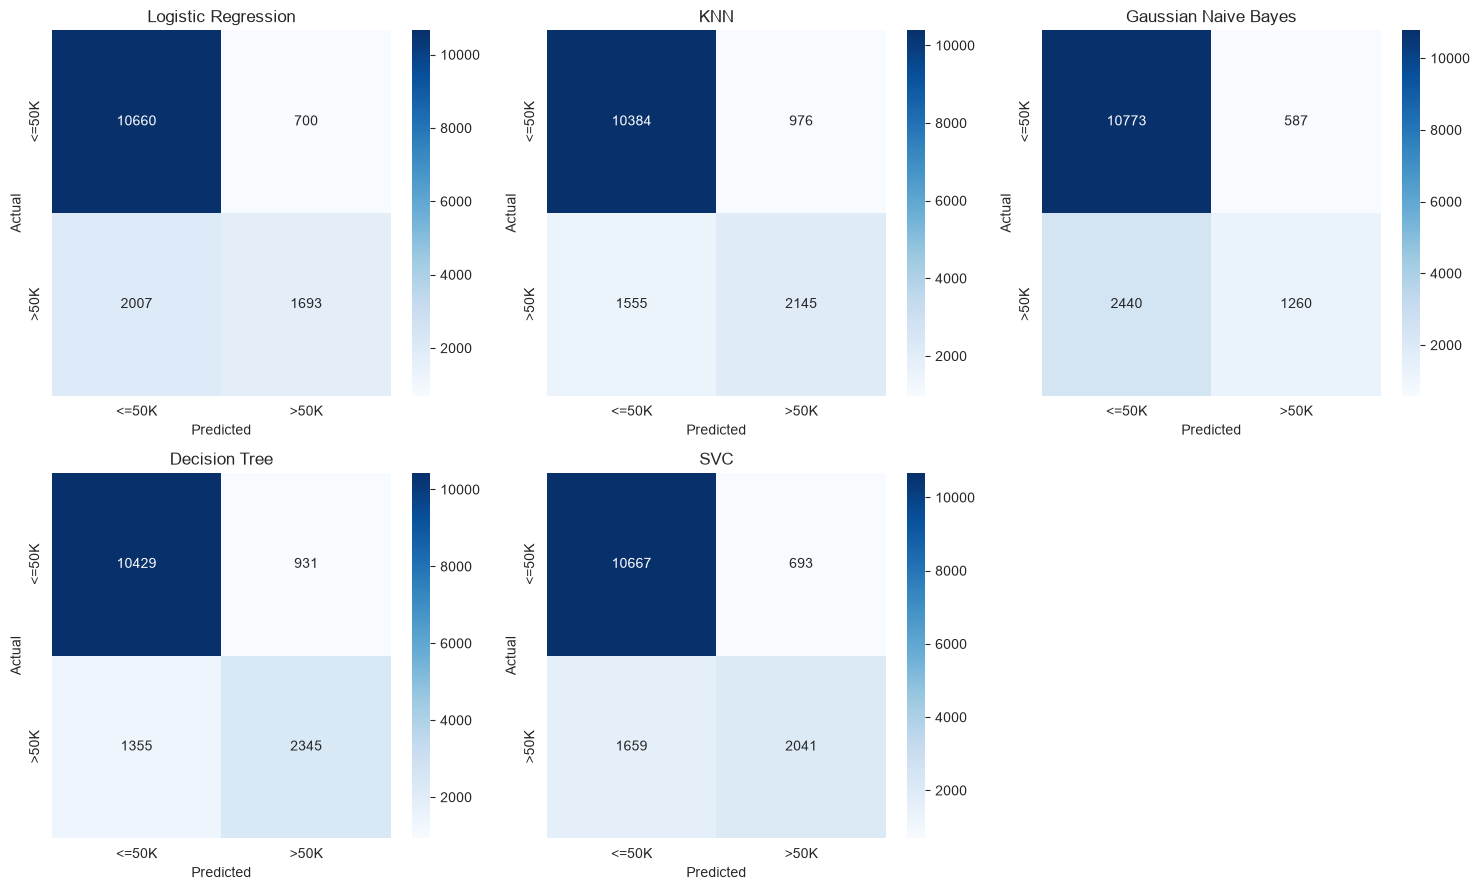

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_le.classes_, yticklabels=target_le.classes_)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for ax in axes[len(models):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../models/classification_confusion_matrices.png', dpi=150)
plt.show()

## 12. Full classification report — best model

In [13]:
best_name = comparison_df.index[0]
print(f'Best model: {best_name}')
print(classification_report(y_test, models[best_name].predict(X_test_scaled), target_names=target_le.classes_))

Best model: Decision Tree
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90     11360
        >50K       0.72      0.63      0.67      3700

    accuracy                           0.85     15060
   macro avg       0.80      0.78      0.79     15060
weighted avg       0.84      0.85      0.84     15060



## 13. Persist fitted models

In [14]:
import joblib

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

name_to_file = {
    'Logistic Regression': 'logistic_regression.pkl',
    'KNN': 'knn_classifier.pkl',
    'Gaussian Naive Bayes': 'gaussian_nb.pkl',
    'Decision Tree': 'decision_tree_classifier.pkl',
    'SVC': 'svc.pkl',
}

for name, fname in name_to_file.items():
    joblib.dump(models[name], MODELS_DIR / fname, compress=3)

joblib.dump(scaler, MODELS_DIR / 'classification_scaler.pkl')
joblib.dump(target_le, MODELS_DIR / 'income_label_encoder.pkl')
print('saved:', list(name_to_file.values()) + ['classification_scaler.pkl', 'income_label_encoder.pkl'])

saved: ['logistic_regression.pkl', 'knn_classifier.pkl', 'gaussian_nb.pkl', 'decision_tree_classifier.pkl', 'svc.pkl', 'classification_scaler.pkl', 'income_label_encoder.pkl']
